# Demographic Features

**Purpose.** Examine the definition, provenance, transformation, grain, joined
completeness, distribution, outliers, redundancy, temporal alignment, retention
decision, and infographic use of the domain features.

This notebook is a diagnostic consumer of the `feature.*` semantic marts. Database
construction owns every feature transformation.

## Setup and authoritative feature definitions

In [1]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
while not (ROOT / "data" / "quoll.duckdb").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
con = duckdb.connect(str(ROOT / "data" / "quoll.duckdb"), read_only=True)
FEATURE_TABLES = ['county_demographic_annual']
EXCLUDED_CATALOG_FEATURES = []
TABLE_NAMES = ", ".join("?" for _ in FEATURE_TABLES)

catalog = con.execute(
    f"SELECT * FROM feature.catalog "
    f"WHERE feature_table IN ({TABLE_NAMES}) "
    f"OR (feature_table IS NULL AND lower(category) = lower(?))"
    f"ORDER BY retained DESC, feature_table, feature_name",
    [*FEATURE_TABLES, 'Demographic'],
).df()
catalog = catalog.loc[
    ~catalog["feature_name"].isin(EXCLUDED_CATALOG_FEATURES)
].copy()
display(catalog)

,geographic_grain,retained,exclusion_reason,feature_table,feature_name,category,definition,unit,source_tables,transformation,temporal_grain,infographic_use
0,county,True,None,county_demographic_annual,age_65_plus_pct,Demographic,Share of residents age 65 or older.,percent,mart.acs_county_demographic_annual,Numeric ACS DP05 percentage estimate.,annual,Feature comparison: Age >= 65 Years
1,county,True,None,county_demographic_annual,communication_barrier_pct,Demographic,Share age 5+ speaking English less than very w...,percent,mart.acs_county_demographic_annual,Numeric ACS DP02 percentage estimate.,annual,Feature comparison: Communication Barrier
2,county,True,None,county_demographic_annual,disability_pct,Demographic,Share of the civilian noninstitutionalized pop...,percent,mart.acs_county_demographic_annual,Numeric ACS DP02 percentage estimate.,annual,Feature comparison: Disability Status
3,county,True,None,county_demographic_annual,net_migration_rate_pct,Demographic,Net domestic plus international migration as a...,percent,mart.statsamerica_population_components_annual...,Total net migration divided by same-year posit...,annual,Feature comparison: Net Migration Rate
4,county,True,None,county_demographic_annual,no_broadband_pct,Demographic,Households without a broadband subscription.,percent,mart.acs_county_demographic_annual,100 minus the ACS broadband-subscription perce...,annual,Feature comparison: No Internet Access
5,county,True,None,county_demographic_annual,total_population,Demographic,County resident population.,people,mart.acs_county_demographic_annual,Numeric ACS population estimate.,annual,Population denominator and context


The catalog above is the answer key for definition, unit, source, transformation,
grain, retention/exclusion, and infographic use. The remaining sections test whether
the built data match those definitions.

## Geographic and temporal grain

In [2]:
inventory_rows = []
for table in FEATURE_TABLES:
    columns = con.execute(f"DESCRIBE feature.{table}").df()["column_name"].tolist()
    time_column = next((c for c in ["year", "climate_month", "housing_month"] if c in columns), None)
    time_sql = (
        f"min({time_column}) AS min_time, max({time_column}) AS max_time, "
        f"count(DISTINCT {time_column}) AS periods"
        if time_column else
        "NULL AS min_time, NULL AS max_time, NULL AS periods"
    )
    row = con.execute(
        f"SELECT count(*) AS rows, count(DISTINCT fips) AS counties, {time_sql} "
        f"FROM feature.{table}"
    ).df()
    row.insert(0, "feature_table", table)
    inventory_rows.append(row)
inventory = pd.concat(inventory_rows, ignore_index=True)
display(inventory)

,feature_table,rows,counties,min_time,max_time,periods
0,county_demographic_annual,114743,3236,1981,2025,45


## Completeness after joins

In [3]:
completeness_frames = []
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    has_year = "year" in schema["column_name"].tolist()
    numeric_columns = schema.loc[
        schema["column_type"].str.contains(
            "DOUBLE|FLOAT|DECIMAL|INTEGER|BIGINT|HUGEINT", case=False, regex=True
        ),
        "column_name",
    ].tolist()
    feature_columns = [
        column for column in numeric_columns
        if column not in {"year", "month"} and not column.endswith("_count")
    ]
    row_count = con.execute(f"SELECT count(*) FROM feature.{table}").fetchone()[0]
    rows = []
    for column in feature_columns:
        if has_year:
            present, first_year, last_year = con.execute(
                f'SELECT count("{column}"), '
                f'min(year) FILTER (WHERE "{column}" IS NOT NULL), '
                f'max(year) FILTER (WHERE "{column}" IS NOT NULL) '
                f"FROM feature.{table}"
            ).fetchone()
            in_scope_rows = con.execute(
                f"SELECT count(*) FROM feature.{table} "
                f"WHERE year BETWEEN ? AND ?",
                [first_year, last_year],
            ).fetchone()[0] if first_year is not None and last_year is not None else 0
        else:
            present = con.execute(
                f'SELECT count("{column}") FROM feature.{table}'
            ).fetchone()[0]
            first_year = last_year = None
            in_scope_rows = row_count
        rows.append({
            "feature_table": table, "feature_name": column,
            "non_null_rows": present, "total_rows": row_count,
            "global_complete_pct": present / row_count * 100 if row_count else np.nan,
            "first_observed_year": first_year,
            "last_observed_year": last_year,
            "in_scope_rows": in_scope_rows,
            "in_scope_complete_pct": (
                present / in_scope_rows * 100 if in_scope_rows else np.nan
            ),
        })
    completeness_frames.append(pd.DataFrame(rows))
completeness = pd.concat(completeness_frames, ignore_index=True)
display(completeness.sort_values(["feature_table", "global_complete_pct"]))

,feature_table,feature_name,non_null_rows,total_rows,global_complete_pct,first_observed_year,last_observed_year,in_scope_rows,in_scope_complete_pct
4,county_demographic_annual,no_broadband_pct,25144,114743,21.913319,2017,2024,25792,97.487593
1,county_demographic_annual,age_65_plus_pct,25768,114743,22.457143,2017,2024,25792,99.906948
3,county_demographic_annual,communication_barrier_pct,31046,114743,27.056988,2015,2024,32236,96.308475
6,county_demographic_annual,net_migration_rate_pct,31415,114743,27.378576,2015,2024,32236,97.453158
2,county_demographic_annual,disability_pct,31428,114743,27.389906,2015,2024,32236,97.493486
0,county_demographic_annual,total_population,32208,114743,28.069686,2015,2024,32236,99.913141
5,county_demographic_annual,total_net_migration,109210,114743,95.177919,1990,2025,113915,95.869727


## Distributions, outliers, and implausible values

In [4]:
frames = []
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    numeric_columns = schema.loc[
        schema["column_type"].str.contains(
            "DOUBLE|FLOAT|DECIMAL|INTEGER|BIGINT|HUGEINT", case=False, regex=True
        ),
        "column_name",
    ].tolist()
    numeric_columns = [
        c for c in numeric_columns
        if c not in {"year", "month"} and not c.endswith("_count")
    ]
    if not numeric_columns:
        continue
    quoted = ", ".join(f'"{column}"' for column in numeric_columns)
    frame = con.execute(f"SELECT {quoted} FROM feature.{table}").df()
    description = frame.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T.reset_index(
        names="feature_name"
    )
    description.insert(0, "feature_table", table)
    q1 = frame.quantile(0.25)
    q3 = frame.quantile(0.75)
    iqr = q3 - q1
    outlier_counts = ((frame.lt(q1 - 1.5 * iqr)) | (frame.gt(q3 + 1.5 * iqr))).sum()
    description["iqr_outlier_count"] = description["feature_name"].map(outlier_counts)
    description["review_flag"] = np.where(
        (description["min"] < 0)
        & description["feature_name"].str.contains(
            "income|wage|population|price|value|precipitation|score", case=False
        ),
        "negative value requires review",
        np.where(description["iqr_outlier_count"] > 0, "distribution has IQR outliers", "none"),
    )
    frames.append(description)
distributions = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
display(distributions)

,feature_table,feature_name,count,mean,std,min,1%,25%,50%,75%,99%,max,iqr_outlier_count,review_flag
0,county_demographic_annual,total_population,32208.0,102210.510960,326808.749491,33.00000,919.140000,11131.500000,25965.000000,67082.750000,1.256005e+06,1.010572e+07,4413,distribution has IQR outliers
1,county_demographic_annual,age_65_plus_pct,25768.0,19.246045,4.813401,2.10000,9.400000,16.200000,18.900000,21.800000,3.340000e+01,8.180000e+01,721,distribution has IQR outliers
2,county_demographic_annual,disability_pct,31428.0,16.030641,4.481436,1.80000,7.500000,12.900000,15.500000,18.700000,2.870000e+01,7.270000e+01,453,distribution has IQR outliers
3,county_demographic_annual,communication_barrier_pct,31046.0,3.403292,4.695708,0.00000,0.100000,0.800000,1.800000,3.900000,2.290000e+01,5.730000e+01,2912,distribution has IQR outliers
4,county_demographic_annual,no_broadband_pct,25144.0,21.233316,9.665551,0.00000,5.500000,14.100000,19.700000,26.800000,4.980000e+01,7.550000e+01,481,distribution has IQR outliers
5,county_demographic_annual,total_net_migration,109210.0,419.086027,4222.517230,-248105.00000,-3758.910000,-76.000000,21.000000,270.000000,1.054364e+04,4.308700e+05,20045,distribution has IQR outliers
6,county_demographic_annual,net_migration_rate_pct,31415.0,0.281894,1.364814,-37.48056,-3.121113,-0.358603,0.172451,0.876773,4.124889e+00,2.567568e+01,1869,distribution has IQR outliers


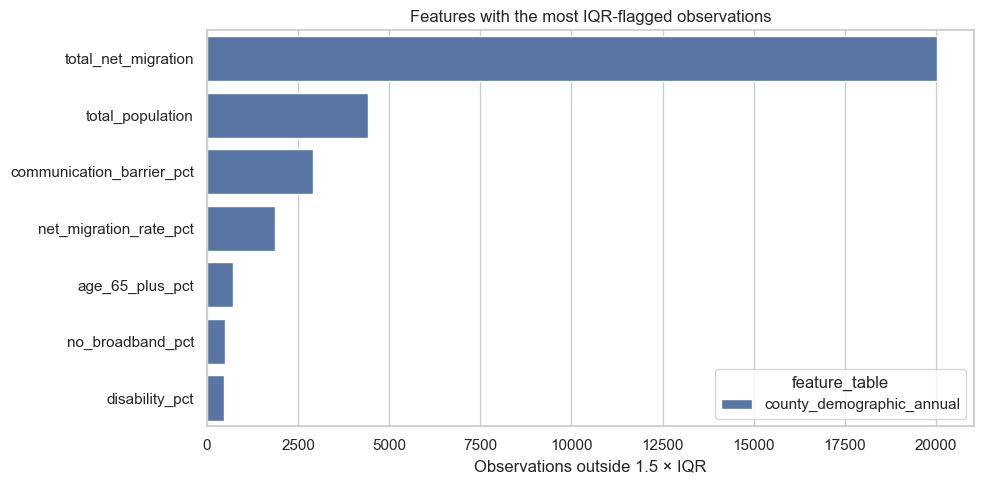

In [5]:
plot_data = distributions.sort_values("iqr_outlier_count", ascending=False).head(12)
if not plot_data.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=plot_data, y="feature_name", x="iqr_outlier_count", hue="feature_table", ax=ax)
    ax.set_title("Features with the most IQR-flagged observations")
    ax.set_xlabel("Observations outside 1.5 × IQR")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

## Redundancy among related features

In [6]:
correlation_frames = []
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    numeric_columns = schema.loc[
        schema["column_type"].str.contains("DOUBLE|FLOAT|DECIMAL", case=False, regex=True),
        "column_name",
    ].tolist()
    if len(numeric_columns) < 2:
        continue
    quoted = ", ".join(f'"{column}"' for column in numeric_columns)
    frame = con.execute(f"SELECT {quoted} FROM feature.{table}").df()
    corr = frame.corr(min_periods=100)
    pairs = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .rename("correlation")
        .reset_index()
        .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
    )
    pairs.insert(0, "feature_table", table)
    correlation_frames.append(pairs)
correlations = pd.concat(correlation_frames, ignore_index=True) if correlation_frames else pd.DataFrame()
if not correlations.empty:
    correlations["absolute_correlation"] = correlations["correlation"].abs()
    display(correlations.sort_values("absolute_correlation", ascending=False).head(30))
else:
    display(pd.DataFrame({"result": ["Fewer than two continuous features were available."]}))

,feature_table,feature_a,feature_b,correlation,absolute_correlation
6,county_demographic_annual,age_65_plus_pct,disability_pct,0.407794,0.407794
12,county_demographic_annual,disability_pct,no_broadband_pct,0.406137,0.406137
2,county_demographic_annual,total_population,communication_barrier_pct,0.338584,0.338584
7,county_demographic_annual,age_65_plus_pct,communication_barrier_pct,-0.313516,0.313516
20,county_demographic_annual,total_net_migration,net_migration_rate_pct,0.296001,0.296001
11,county_demographic_annual,disability_pct,communication_barrier_pct,-0.258425,0.258425
1,county_demographic_annual,total_population,disability_pct,-0.229602,0.229602
19,county_demographic_annual,no_broadband_pct,net_migration_rate_pct,-0.227932,0.227932
3,county_demographic_annual,total_population,no_broadband_pct,-0.216861,0.216861
0,county_demographic_annual,total_population,age_65_plus_pct,-0.204023,0.204023


## Temporal alignment

In [7]:
alignment_frames = []
for table in FEATURE_TABLES:
    columns = con.execute(f"DESCRIBE feature.{table}").df()["column_name"].tolist()
    time_column = next((c for c in ["year", "climate_month", "housing_month"] if c in columns), None)
    flags = [c for c in columns if c.startswith("has_")]
    if time_column and flags:
        aggregates = ", ".join(
            f'avg(cast("{flag}" AS INTEGER)) * 100 AS "{flag}_pct"' for flag in flags
        )
        alignment = con.execute(
            f"SELECT {time_column}, count(DISTINCT fips) AS counties, {aggregates} "
            f"FROM feature.{table} GROUP BY {time_column} ORDER BY {time_column}"
        ).df()
        alignment.insert(0, "feature_table", table)
        alignment_frames.append(alignment)
    elif time_column:
        alignment = con.execute(
            f"SELECT {time_column}, count(DISTINCT fips) AS counties "
            f"FROM feature.{table} GROUP BY {time_column} ORDER BY {time_column}"
        ).df()
        alignment.insert(0, "feature_table", table)
        alignment_frames.append(alignment)
alignment = pd.concat(alignment_frames, ignore_index=True) if alignment_frames else pd.DataFrame()
display(alignment)

,feature_table,year,counties,has_acs_demographic_pct,has_statsamerica_migration_pct
0,county_demographic_annual,1981,92,0.000000,100.000000
1,county_demographic_annual,1982,92,0.000000,100.000000
2,county_demographic_annual,1983,92,0.000000,100.000000
3,county_demographic_annual,1984,92,0.000000,100.000000
4,county_demographic_annual,1985,92,0.000000,100.000000
5,county_demographic_annual,1986,92,0.000000,100.000000
6,county_demographic_annual,1987,92,0.000000,100.000000
7,county_demographic_annual,1988,92,0.000000,100.000000
8,county_demographic_annual,1989,92,0.000000,100.000000
9,county_demographic_annual,1990,3139,0.000000,100.000000


## Retention and infographic use

Retention is decided in `feature.catalog`, not from visual inspection in this
notebook. A feature is retained when its definition is interpretable, its unit and
grain are stable, its completeness is adequate for its intended comparison, and it
does not duplicate the outcome or a stronger related measure. The `infographic_use`
and `exclusion_reason` catalog fields record the current decision.

In [8]:
display(catalog[[
    "feature_name", "retained", "exclusion_reason", "infographic_use",
    "source_tables", "transformation"
]])
con.close()

,feature_name,retained,exclusion_reason,infographic_use,source_tables,transformation
0,age_65_plus_pct,True,None,Feature comparison: Age >= 65 Years,mart.acs_county_demographic_annual,Numeric ACS DP05 percentage estimate.
1,communication_barrier_pct,True,None,Feature comparison: Communication Barrier,mart.acs_county_demographic_annual,Numeric ACS DP02 percentage estimate.
2,disability_pct,True,None,Feature comparison: Disability Status,mart.acs_county_demographic_annual,Numeric ACS DP02 percentage estimate.
3,net_migration_rate_pct,True,None,Feature comparison: Net Migration Rate,mart.statsamerica_population_components_annual...,Total net migration divided by same-year posit...
4,no_broadband_pct,True,None,Feature comparison: No Internet Access,mart.acs_county_demographic_annual,100 minus the ACS broadband-subscription perce...
5,total_population,True,None,Population denominator and context,mart.acs_county_demographic_annual,Numeric ACS population estimate.
